# oil-price-pgm

**Author:** Sana Ur Rehman Arain

**Profession:** Data Scientist | Data Analyst 

**Created:** June 2026  

---

## Copyright & Usage Notice

This project is an original work created by **Sana Ur Rehman Arain** for educational purposes, 
professional portfolio development, and showcasing data science skills.

You may view this project for learning and reference purposes. However, 
you may not copy, reproduce, redistribute, publish, or claim this work as 
your own without explicit permission and proper **credit** to the author.

If you use any part of this project, please provide appropriate attribution.

© 2026 Sana Ur Rehman Arain. All rights reserved.

## Citation

If you reference or build upon this project, please provide appropriate
credit to the original author.

For citation information, see the project's README and CITATION.cff file.

# Python Workspace Setup

In [6]:
import os

def setup_project_workspace():
    print("Initializing Project Workspace...")
    
    # Define the files to create
    files_to_create = [
        "ProjectReport.docx", 
        "code.ipynb",         
        "README.md",          
        "TASKS.md",           
        "requirements.txt",   
        ".env",               
        ".gitignore"          
    ]
    
    for file_name in files_to_create:
        if not os.path.exists(file_name):
            # Create an empty file
            with open(file_name, 'w') as f:
                # Add basic boilerplate to specific files
                if file_name == ".gitignore":
                    f.write(".env\n__pycache__/\n.ipynb_checkpoints/\n")
                elif file_name == "requirements.txt":
                    f.write("pandas\nnumpy\nyfinance\nfredapi\npython-dotenv\nmatplotlib\nseaborn\npgmpy\nhmmlearn\n")
                elif file_name == "README.md":
                    f.write("# Project 2: Methodology & Regime Detection\n")
                pass
            print(f" [+] Created: {file_name}")
        else:
            print(f" [!] Already exists: {file_name}")
            
    print("\nWorkspace setup complete! Please configure the .env file.")

setup_project_workspace()

Initializing Project Workspace...
 [!] Already exists: ProjectReport.docx
 [!] Already exists: code.ipynb
 [!] Already exists: README.md
 [!] Already exists: TASKS.md
 [!] Already exists: requirements.txt
 [!] Already exists: .env
 [!] Already exists: .gitignore

Workspace setup complete! Please configure the .env file.


# STEP 2: REGIME DETECTION USING HIDDEN MARKOV MODELS

--- STEP 2: HMM REGIME DETECTION ---


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



=> Did the Baum-Welch EM algorithm converge? True

--- LEARNED EMISSION PARAMETERS (Gaussian Means & Variances) ---
State 0 [Bull (High Growth)]: Mean = 0.0115, Variance = 0.0051
State 1 [Stagnant (Mean-Reverting)]: Mean = 0.0085, Variance = 0.0059
State 2 [Bear (High Volatility/Drawdown)]: Mean = -0.0926, Variance = 0.0837

--- LEARNED TRANSITION MATRIX ---
[[0.003 0.997 0.   ]
 [0.934 0.028 0.039]
 [0.099 0.232 0.669]]


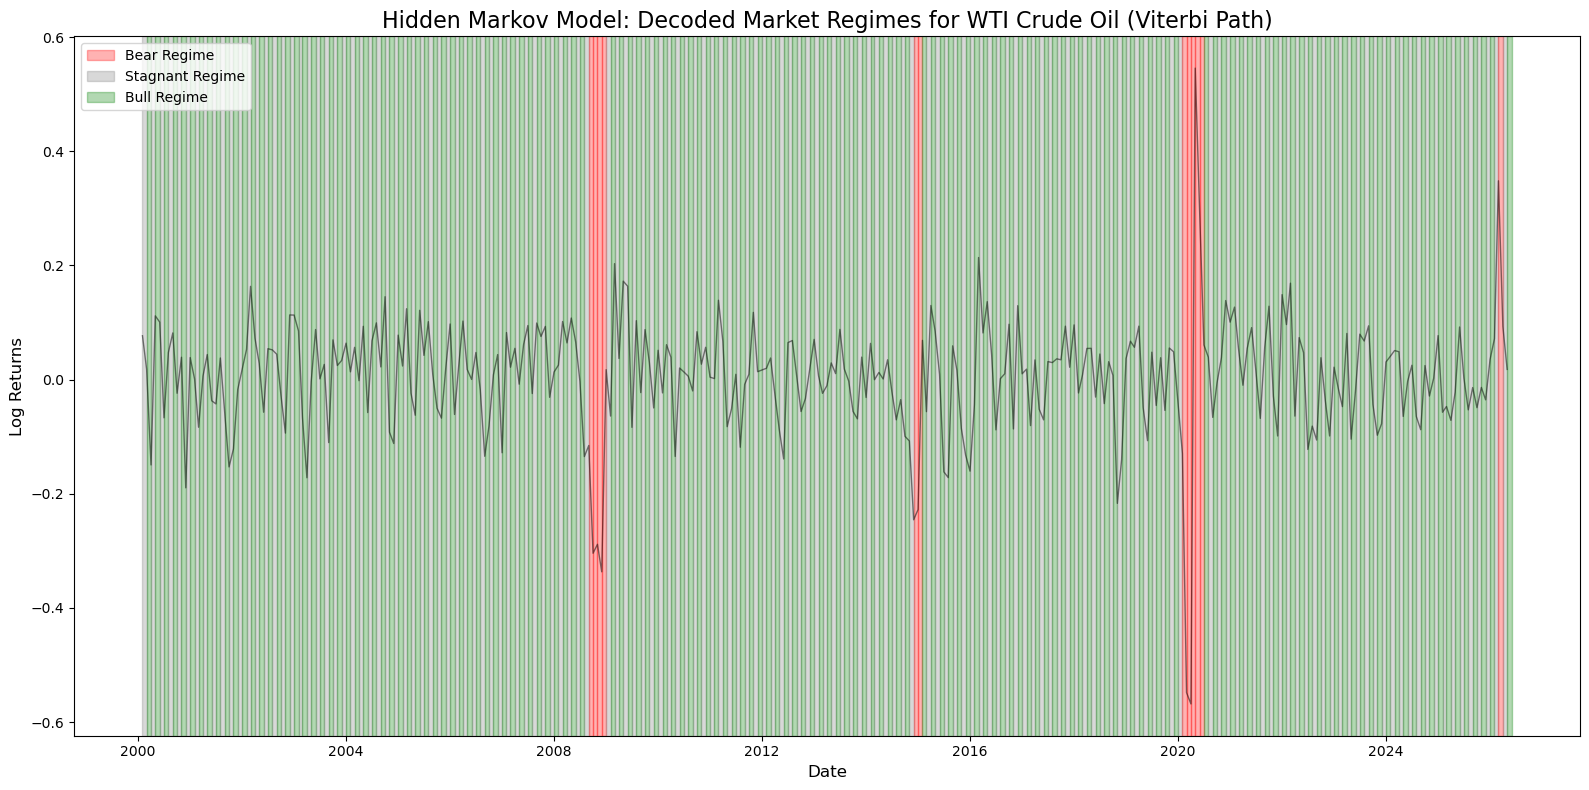


--- SAMPLE IDENTIFIED DATES ---
Recent Bear Months:
            WTI_Oil_Price  Regime_ID                      Regime_Name
2020-05-01       0.545621          2  Bear (High Volatility/Drawdown)
2020-06-01       0.293704          2  Bear (High Volatility/Drawdown)
2026-03-01       0.348206          2  Bear (High Volatility/Drawdown)

Recent Bull Months:
            WTI_Oil_Price  Regime_ID         Regime_Name
2025-11-01      -0.013725          0  Bull (High Growth)
2026-01-01       0.035085          0  Bull (High Growth)
2026-05-01       0.017881          0  Bull (High Growth)

Recent Stagnant Months:
            WTI_Oil_Price  Regime_ID                Regime_Name
2025-12-01      -0.035418          1  Stagnant (Mean-Reverting)
2026-02-01       0.071809          1  Stagnant (Mean-Reverting)
2026-04-01       0.093338          1  Stagnant (Mean-Reverting)


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from hmmlearn import hmm

print("--- STEP 2: HMM REGIME DETECTION ---")

df_stationary = pd.read_csv(
    "df_stationary.csv",
    index_col=0,
    parse_dates=True
)

# 1. Prepare the Target Variable
# We will use the stationary WTI Oil Returns from Project 1
X = df_stationary[['WTI_Oil_Price']].dropna().values

# 2. Initialize and Train the Hidden Markov Model (Baum-Welch Algorithm)
# We specify 3 components assuming: Bull, Bear, and Stagnant regimes
np.random.seed(42) # For reproducibility
model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=1000)
model.fit(X)

# VERIFY CONVERGENCE
print(f"\n=> Did the Baum-Welch EM algorithm converge? {model.monitor_.converged}")

# 3. Decode the Hidden States (Viterbi Algorithm)
hidden_states = model.predict(X)

# 4. Map States to Regime Names based on Means
state_means = model.means_.flatten()
state_variances = np.array([np.diag(model.covars_[i]) for i in range(3)]).flatten()

sorted_indices = np.argsort(state_means)
bear_state = sorted_indices[0]      # Lowest mean (likely negative)
stagnant_state = sorted_indices[1]  # Middle mean (near zero)
bull_state = sorted_indices[2]      # Highest mean (positive)

regime_map = {
    bear_state: "Bear (High Volatility/Drawdown)",
    stagnant_state: "Stagnant (Mean-Reverting)",
    bull_state: "Bull (High Growth)"
}

# PRINT EMISSION PARAMETERS
print("\n--- LEARNED EMISSION PARAMETERS (Gaussian Means & Variances) ---")
for i in range(3):
    reg_name = regime_map[i]
    print(f"State {i} [{reg_name}]: Mean = {state_means[i]:.4f}, Variance = {state_variances[i]:.4f}")

# PRINT TRANSITION MATRIX
print("\n--- LEARNED TRANSITION MATRIX ---")
print(np.round(model.transmat_, 3))

# 5. Plot the Regimes
fig, ax = plt.subplots(figsize=(16, 8))
colors = {bear_state: 'red', stagnant_state: 'gray', bull_state: 'green'}

# Plot the actual log returns
ax.plot(df_stationary.index, df_stationary['WTI_Oil_Price'], color='black', linewidth=1, alpha=0.5, label='WTI Log Returns')

# Shade the background based on the decoded Viterbi state
for i in range(len(hidden_states)):
    ax.axvspan(df_stationary.index[i], 
               df_stationary.index[i] + pd.DateOffset(months=1), 
               color=colors[hidden_states[i]], alpha=0.3)

# Create custom legend for the regimes
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', alpha=0.3, label='Bear Regime')
gray_patch = mpatches.Patch(color='gray', alpha=0.3, label='Stagnant Regime')
green_patch = mpatches.Patch(color='green', alpha=0.3, label='Bull Regime')
ax.legend(handles=[red_patch, gray_patch, green_patch], loc='upper left')

plt.title('Hidden Markov Model: Decoded Market Regimes for WTI Crude Oil (Viterbi Path)', fontsize=16)
plt.ylabel('Log Returns', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

# 6. Extract exact dates for the report
df_regimes = df_stationary[['WTI_Oil_Price']].copy()
df_regimes['Regime_ID'] = hidden_states
df_regimes['Regime_Name'] = df_regimes['Regime_ID'].map(regime_map)

print("\n--- SAMPLE IDENTIFIED DATES ---")
print("Recent Bear Months:")
print(df_regimes[df_regimes['Regime_ID'] == bear_state].tail(3))
print("\nRecent Bull Months:")
print(df_regimes[df_regimes['Regime_ID'] == bull_state].tail(3))

print("\nRecent Stagnant Months:")
print(df_regimes[df_regimes['Regime_ID'] == stagnant_state].tail(3))

In [8]:
import pandas as pd
from pgmpy.estimators import HillClimbSearch, BIC

# Toy Example: 3 Variables (Rain, Sprinkler, Wet Grass)
toy_data = pd.DataFrame({
    'Rain': [0, 1, 1, 0, 1],
    'Sprinkler': [1, 0, 0, 1, 0],
    'Wet_Grass': [1, 1, 1, 1, 1]
})
hc_toy = HillClimbSearch(toy_data)
best_toy_model = hc_toy.estimate(scoring_method=BIC(toy_data))
print("Toy Example Edges:", best_toy_model.edges())

C:\Users\Yahya\AppData\Local\Temp\ipykernel_1848\711452367.py:10: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc_toy = HillClimbSearch(toy_data)


  0%|          | 0/1000000 [00:00<?, ?it/s]

Toy Example Edges: [('Rain', 'Sprinkler')]


# Steps 8 & 9: Bayesian Network Structure Learning

--- STEP 8 & 9: HILL CLIMB SEARCH (DAG LEARNING) ---
Data discretized into binary market states (1 = Up, 0 = Down).
Running heuristic search to find optimal causal structure (this may take a few seconds)...


c:\Users\Yahya\anaconda3\envs\myenv\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (
C:\Users\Yahya\AppData\Local\Temp\ipykernel_4128\3368530977.py:14: FutureWarning: HillClimbSearch is deprecated and will be removed in v1.3.0. Please use
            pgmpy.causal_discovery.HillClimbSearch instead.
  hc = HillClimbSearch(df_discrete)


  0%|          | 0/1000000 [00:00<?, ?it/s]


Learned Causal Edges (Direction of Influence):
[WTI_Oil_Price] ---> causes ---> [Energy_Sector_ETF]
[Industrial_Production] ---> causes ---> [Cap_Util_Oil_Gas]
[CPI_Energy] ---> causes ---> [WTI_Oil_Price]
[SP500] ---> causes ---> [USD_Index]
[Energy_Sector_ETF] ---> causes ---> [SP500]


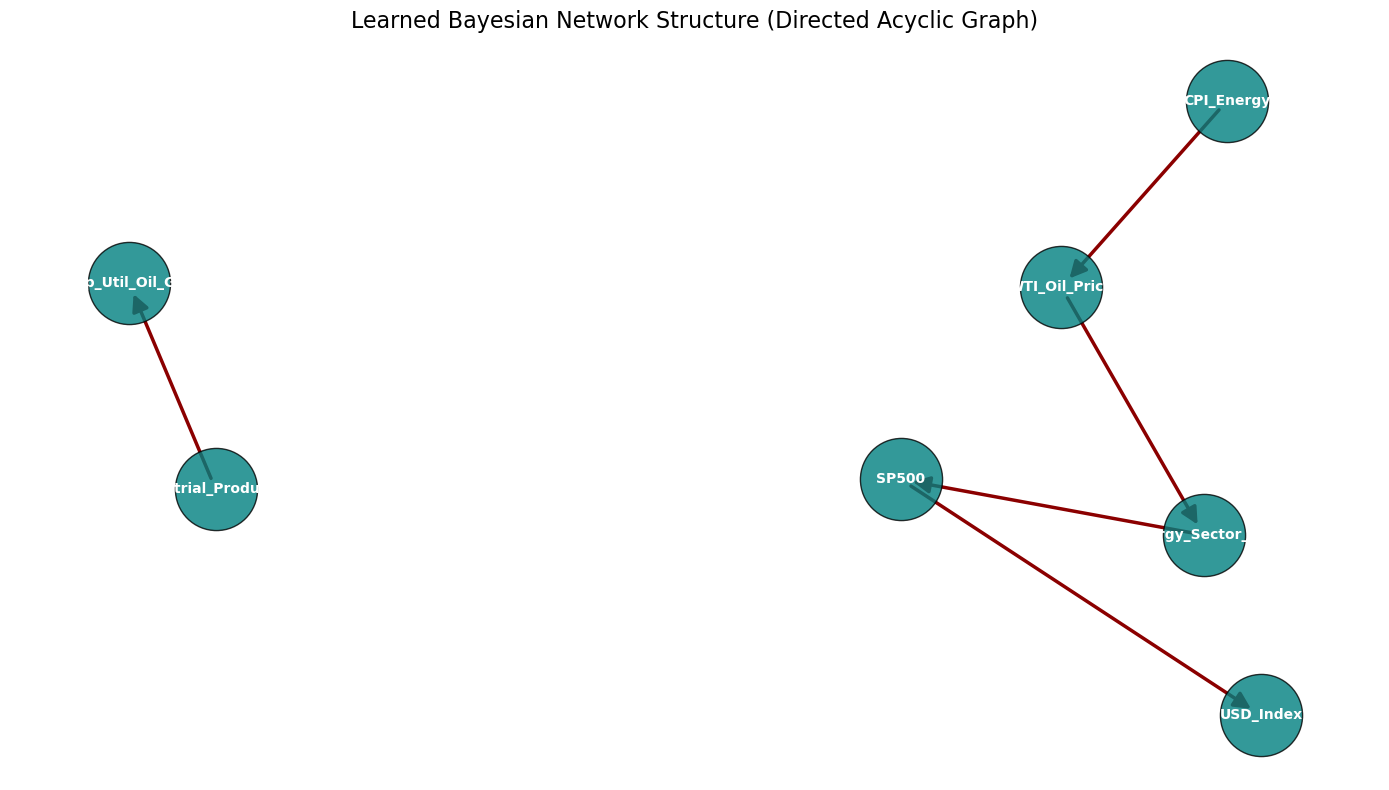

In [3]:
import networkx as nx
from pgmpy.estimators import HillClimbSearch, BIC

print("--- STEP 8 & 9: HILL CLIMB SEARCH (DAG LEARNING) ---")

# 1. Discretize the Data
# pgmpy structure learning requires discrete states. 
# We convert continuous log returns into binary states: 1 (Up/Positive) and 0 (Down/Negative)
df_discrete = (df_stationary > 0).astype(int)

print("Data discretized into binary market states (1 = Up, 0 = Down).")

# 2. Initialize the Search Algorithm
hc = HillClimbSearch(df_discrete)

# 3. Estimate the Directed Acyclic Graph (DAG) using the BIC Score
print("Running heuristic search to find optimal causal structure (this may take a few seconds)...")
best_model = hc.estimate(scoring_method=BIC(df_discrete))

# 4. Extract the Learned Edges (Causal Arrows)
edges = best_model.edges()
print("\nLearned Causal Edges (Direction of Influence):")
if len(edges) == 0:
    print("No edges discovered. Variables are strictly independent under BIC penalty.")
else:
    for edge in edges:
        print(f"[{edge[0]}] ---> causes ---> [{edge[1]}]")

# 5. Visualize the Bayesian Network
plt.figure(figsize=(14, 8))

# Create a NetworkX directed graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Include variables that might be isolated (no edges)
for col in df_discrete.columns:
    if col not in G.nodes():
        G.add_node(col)

# Set layout for visualization
pos = nx.spring_layout(G, seed=42, k=0.9) # k spacing

# Draw nodes and edges
nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='teal', alpha=0.8, edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', font_color='white')
nx.draw_networkx_edges(G, pos, edge_color='darkred', arrows=True, arrowsize=25, width=2.5)

plt.title("Learned Bayesian Network Structure (Directed Acyclic Graph)", fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()